# Florence-2 : détection par thésaurus contrôlé + localisation

Notebook construit pour être **directement comparable** au notebook Molmo2 (mêmes fichiers d'entrée `IMAGE_PATH`/`THESAURUS_PATH`, même structure de sortie image annotée + fichier texte).

**Différence méthodologique importante entre les deux modèles**, à garder en tête pour l'interprétation du benchmark :
- **Molmo2** est un modèle *instruction-following* : on peut littéralement lui donner la liste du thésaurus dans le prompt et lui demander de répondre uniquement avec les mots présents.
- **Florence-2** est un modèle *prompt-based* à tâches fixes (`<OD>`, `<CAPTION>`, `<CAPTION_TO_PHRASE_GROUNDING>`, etc. — voir la [doc HF](https://huggingface.co/docs/transformers/model_doc/florence2#notes)). Il ne sait pas nativement "lire une liste et cocher ce qui est présent". On approxime donc l'étape de détection en deux temps :
  1. génération d'une description libre de l'image (`<MORE_DETAILED_CAPTION>` + `<DENSE_REGION_CAPTION>`)
  2. mise en correspondance (mot-à-mot, insensible à la casse) entre cette description libre et les termes du thésaurus (`Term_angl`)
- L'étape de **localisation** est ensuite comparable : comme pour le *pointing* de Molmo2, on utilise `<CAPTION_TO_PHRASE_GROUNDING>` terme par terme pour obtenir des bounding boxes.

**À faire avant de lancer** : Runtime → Modifier le type d'exécution → GPU (T4 minimum).

## 1. Installation

In [ ]:
!pip install -q "transformers==4.57.1" accelerate torch torchvision "pillow==11.1.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 73.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [ ]:
import transformers, torch, PIL
print("transformers:", transformers.__version__)
print("CUDA:", torch.cuda.is_available())
print("pillow:", PIL.__version__)

transformers: 5.13.1
CUDA: True
pillow: 11.3.0


## 2. Upload des fichiers

Uploadez ici votre image (ex. `Abbeville-16_10__8.jpg`) et votre thésaurus (`thesau_angl.json`) — utilisez les mêmes fichiers que pour le notebook Molmo2 afin de pouvoir comparer directement les résultats.

In [ ]:
from google.colab import files
uploaded = files.upload()
print(list(uploaded.keys()))

Saving Celestins-Qu-2b_4__68.jpg to Celestins-Qu-2b_4__68.jpg
Saving thesau_angl.json to thesau_angl.json
['Celestins-Qu-2b_4__68.jpg', 'thesau_angl.json']


95 termes chargés depuis le thésaurus.


config.json:   0%|          | 0.00/2.40k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.55GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/917 [00:00<?, ?it/s]

...

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.75M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/22.4k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/147k [00:00<?, ?B/s]


Description détaillée (brute) :
The image shows the entrance of a building with two large red doors. The doors are made of stone and have intricate carvings on the top and sides. On the left side of the doors, there is a statue of a woman's head with a crown on her head. The statue is of a man with a beard and a long beard, wearing a long robe and holding a staff. The man is standing in front of the door with his arms crossed and a serious expression on his face. The door on the right side is also made of red wood and has a similar design to the one on the left. Above the statue, there are two ornate decorations with flowers and leaves. The overall style of the building appears to be old and weathered.

Régions détectées (brute) :
{'bboxes': [[771, 579, 1256, 1720], [82, 764, 501, 1551], [511, 584, 813, 1560], [169, 292, 405, 638], [232, 345, 337, 482], [622, 642, 720, 771]], 'labels': ['red wooden door', 'red wooden double doors', 'Roman goddess statue on stone wall with red door', '

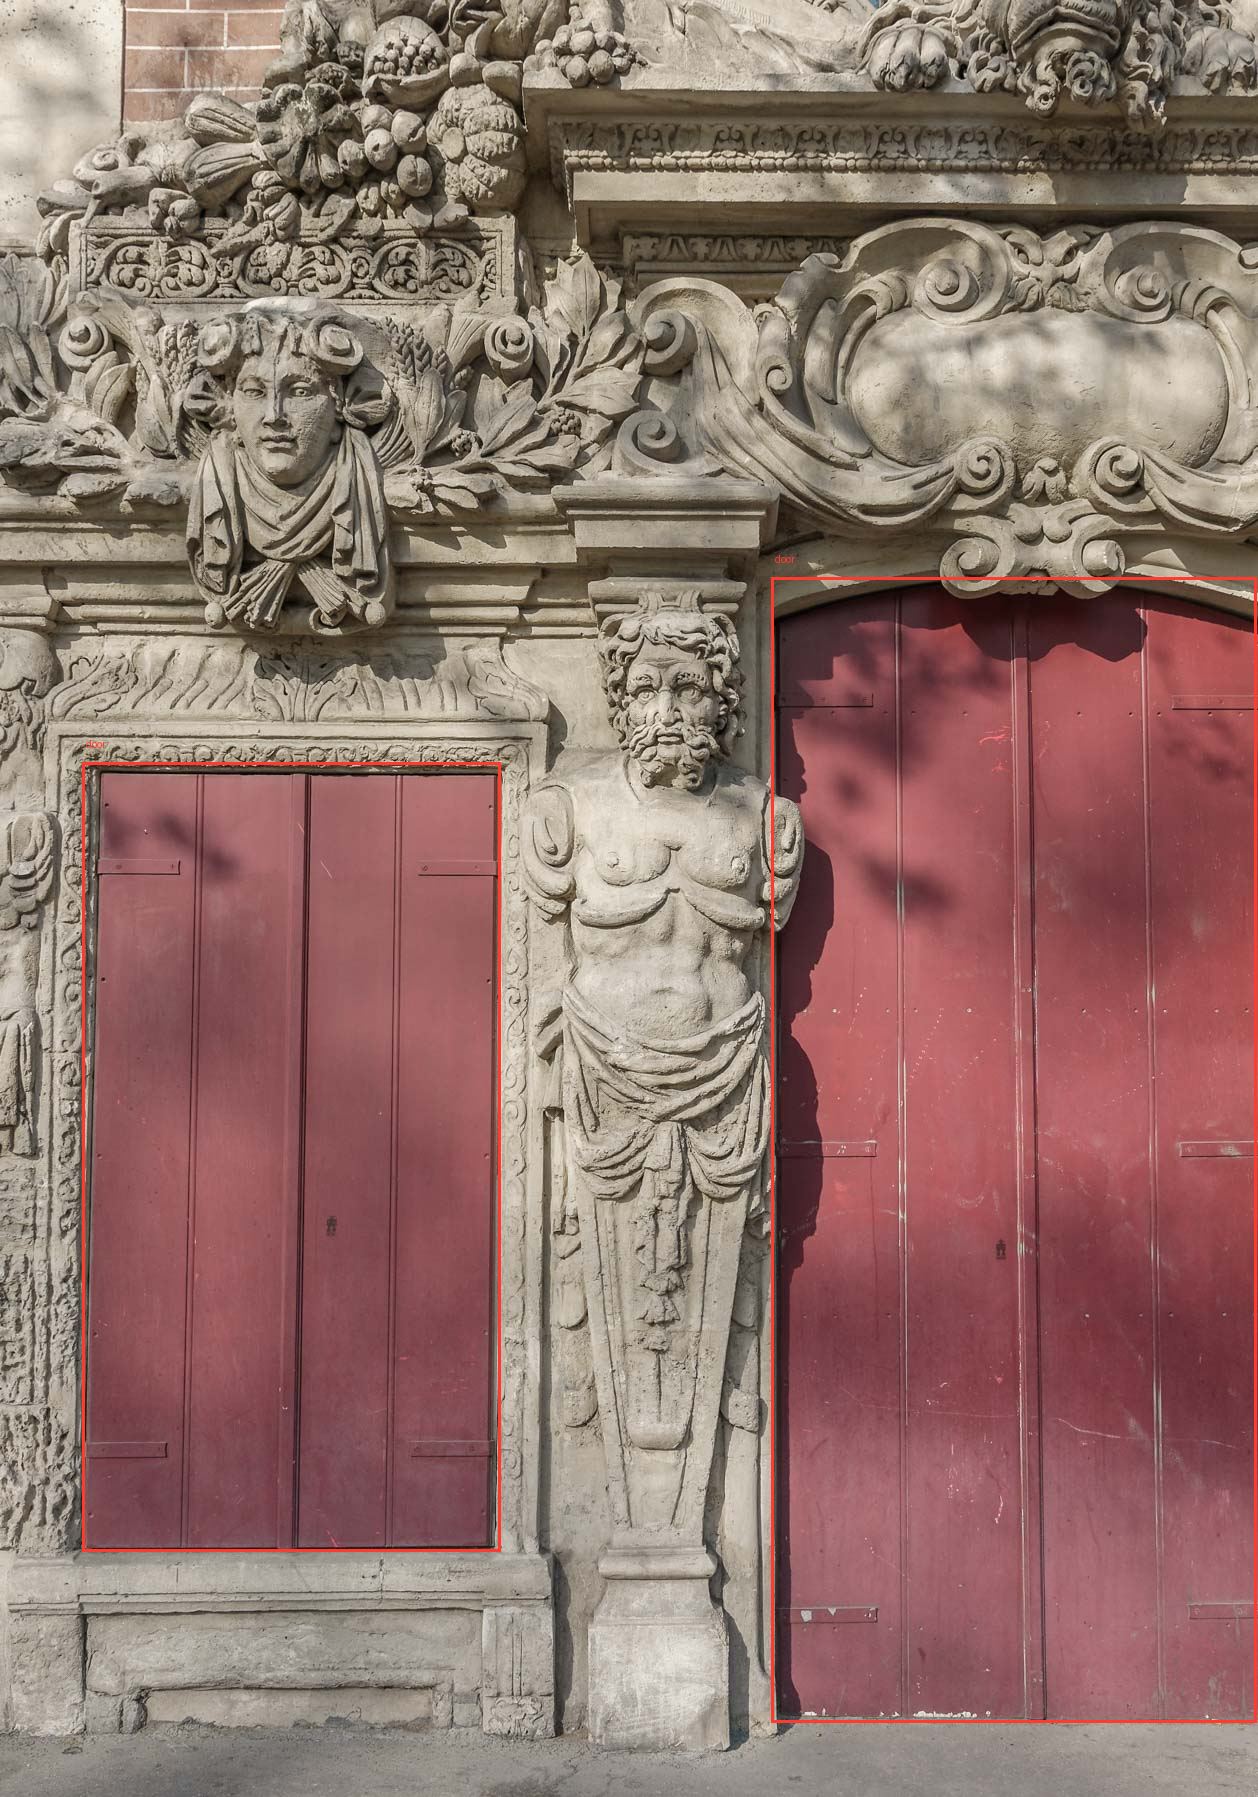


Résultats texte sauvegardés : Celestin_florence2_results.txt


In [ ]:
"""
Florence-2 : détection de mots-clés contrôlés (thésaurus) + localisation (grounding) sur une image.

Utilise l'implémentation NATIVE de Florence-2 dans transformers (classe
Florence2ForConditionalGeneration, disponible depuis transformers >= ~4.55),
avec les checkpoints re-uploadés sous florence-community/ qui sont compatibles
avec cette implémentation native (pas besoin de trust_remote_code=True, donc
plus robuste dans le temps que l'ancien chargement via microsoft/Florence-2-*
+ AutoModelForCausalLM, qui casse à chaque grosse mise à jour de transformers).

Setup recommandé (une seule fois, dans un notebook Colab tout neuf, GPU T4 ou mieux) :
    !pip install -q transformers==4.57.1 accelerate torch torchvision pillow
Puis Runtime > Restart session avant d'exécuter ce script si vous changez de version.
"""

import json
import re
from PIL import Image, ImageDraw, ImageFont
from transformers import AutoProcessor, Florence2ForConditionalGeneration
import torch

# ----------------------------------------------------------------------
# Config
# ----------------------------------------------------------------------
IMAGE_PATH = "Celestins-Qu-2b_4__68.jpg"
THESAURUS_PATH = "thesau_angl.json"
MODEL_ID = "florence-community/Florence-2-large"
MAX_NEW_TOKENS = 1024
NUM_BEAMS = 3
OUTPUT_IMAGE_PATH = "Celestin_florence2_annotated.jpg"
OUTPUT_TXT_PATH = "Celestin_florence2_results.txt"

TERM_FIELD = "Term_angl"  # thésaurus en anglais ; utilise "Term_TMS" pour la version française

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32

# ----------------------------------------------------------------------
# 1. Chargement du thésaurus
# ----------------------------------------------------------------------
with open(THESAURUS_PATH, "r", encoding="utf-8") as f:
    thesaurus_raw = json.load(f)

words = []
term_to_category = {}
if isinstance(thesaurus_raw, list):
    for fiche in thesaurus_raw:
        if isinstance(fiche, dict) and TERM_FIELD in fiche and isinstance(fiche[TERM_FIELD], str):
            term = fiche[TERM_FIELD].strip()
            if term:
                words.append(term)
                term_to_category[term.lower()] = fiche.get("cluster", "")
else:
    raise ValueError("Structure inattendue : une liste de fiches était attendue.")

words = sorted(set(words))
print(f"{len(words)} termes chargés depuis le thésaurus.")

# ----------------------------------------------------------------------
# 2. Chargement du modèle
# ----------------------------------------------------------------------
model = Florence2ForConditionalGeneration.from_pretrained(
    MODEL_ID, dtype=dtype, device_map="auto"
)
processor = AutoProcessor.from_pretrained(MODEL_ID)

image = Image.open(IMAGE_PATH).convert("RGB")


def ask_florence(task_prompt, text_input=None):
    prompt = task_prompt if text_input is None else task_prompt + text_input
    inputs = processor(text=prompt, images=image, return_tensors="pt")
    inputs = {k: v.to(device, dtype) if v.dtype.is_floating_point else v.to(device) for k, v in inputs.items()}

    generated_ids = model.generate(
        input_ids=inputs["input_ids"],
        pixel_values=inputs["pixel_values"],
        max_new_tokens=MAX_NEW_TOKENS,
        num_beams=NUM_BEAMS,
        do_sample=False,
    )
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
    parsed = processor.post_process_generation(
        generated_text, task=task_prompt, image_size=(image.width, image.height)
    )
    return parsed[task_prompt]


# ----------------------------------------------------------------------
# 3. Étape 1 : détection — description libre puis matching contre le thésaurus
# ----------------------------------------------------------------------
detailed_caption = ask_florence("<MORE_DETAILED_CAPTION>")
dense_region = ask_florence("<DENSE_REGION_CAPTION>")

print("\nDescription détaillée (brute) :")
print(detailed_caption)
print("\nRégions détectées (brute) :")
print(dense_region)

# on regroupe tout le texte libre généré pour le matching
region_labels = dense_region.get("labels", []) if isinstance(dense_region, dict) else []
free_text_pool = " ".join([detailed_caption] + region_labels).lower()

words_lower = {w.lower(): w for w in words}
validated = []
for w_lower, w_original in words_lower.items():
    # matching mot-entier / expression, insensible à la casse
    pattern = r"\b" + re.escape(w_lower) + r"\b"
    if re.search(pattern, free_text_pool):
        validated.append(w_original)

validated = sorted(set(validated))
rejected_examples = sorted(set(region_labels) - {w.lower() for w in validated})

print("\nMots validés (présents dans le thésaurus, détectés dans la description) :")
print(validated)
if rejected_examples:
    print("\nLabels de régions détectés hors thésaurus (ignorés, à titre indicatif) :")
    print(rejected_examples)

# ----------------------------------------------------------------------
# 4. Étape 2 : localisation — grounding par terme validé
# ----------------------------------------------------------------------
term_boxes = {}  # terme -> liste de [x0, y0, x1, y1] en pixels

for term in validated:
    out = ask_florence("<CAPTION_TO_PHRASE_GROUNDING>", term)
    bboxes = out.get("bboxes", [])
    term_boxes[term] = bboxes
    print(f"\n[{term}] bounding boxes : {bboxes}")

# ----------------------------------------------------------------------
# 5. Rendu de l'image annotée
# ----------------------------------------------------------------------
annotated = image.copy()
draw = ImageDraw.Draw(annotated)

palette = [
    "#FF3B30", "#34C759", "#007AFF", "#FF9500", "#AF52DE",
    "#FF2D55", "#5AC8FA", "#FFCC00", "#4CD964", "#5856D6",
]

try:
    font = ImageFont.truetype("DejaVuSans-Bold.ttf", 22)
except Exception:
    font = ImageFont.load_default()

for i, (term, boxes) in enumerate(term_boxes.items()):
    color = palette[i % len(palette)]
    for box in boxes:
        x0, y0, x1, y1 = box
        draw.rectangle([x0, y0, x1, y1], outline=color, width=3)
        draw.text((x0 + 4, max(y0 - 24, 0)), term, fill=color, font=font)

annotated.save(OUTPUT_IMAGE_PATH)
print(f"\nImage annotée sauvegardée : {OUTPUT_IMAGE_PATH}")

try:
    from IPython.display import display
    display(annotated)
except ImportError:
    pass

# ----------------------------------------------------------------------
# 6. Sauvegarde des résultats texte
# ----------------------------------------------------------------------
with open(OUTPUT_TXT_PATH, "w", encoding="utf-8") as f:
    f.write(f"Image : {IMAGE_PATH}\n")
    f.write(f"Modèle : {MODEL_ID}\n")
    f.write(f"Thésaurus : {THESAURUS_PATH} ({len(words)} termes)\n\n")

    f.write("=== Description détaillée (brute) ===\n")
    f.write(detailed_caption.strip() + "\n\n")

    f.write("=== Régions détectées, labels bruts ===\n")
    f.write(", ".join(region_labels) + "\n\n")

    f.write("=== Mots validés (présents dans le thésaurus) ===\n")
    f.write(", ".join(validated) + "\n\n")

    if rejected_examples:
        f.write("=== Labels hors thésaurus (ignorés) ===\n")
        f.write(", ".join(rejected_examples) + "\n\n")

    f.write("=== Bounding boxes par terme (pixels, x0 y0 x1 y1) ===\n")
    for term, boxes in term_boxes.items():
        boxes_str = "; ".join(f"({b[0]:.1f}, {b[1]:.1f}, {b[2]:.1f}, {b[3]:.1f})" for b in boxes)
        f.write(f"{term}: {boxes_str if boxes_str else '(aucune bbox)'}\n")

print(f"\nRésultats texte sauvegardés : {OUTPUT_TXT_PATH}")

## 3. Téléchargement des résultats

In [ ]:
from google.colab import files as gfiles
gfiles.download(OUTPUT_IMAGE_PATH)
gfiles.download(OUTPUT_TXT_PATH)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes pour la comparaison Florence-2 vs Molmo2

- **Détection** : Florence-2 n'est pas comparé "à armes égales" sur cette étape — il ne lit pas le thésaurus, on matche a posteriori sa description libre. Un terme peut donc être manqué non pas parce que l'objet est absent, mais parce que Florence-2 ne l'a pas nommé avec exactement le même mot dans sa caption (ex. il dit "window" de façon générique là où le thésaurus attend "oriel window").
- **Localisation** : ici la comparaison est plus directe, les deux modèles reçoivent le même terme validé et doivent le localiser (grounding par phrase pour Florence-2, pointing pour Molmo2). Les coordonnées sont dans les deux cas ramenées en pixels absolus pour rester comparables (Florence-2 les donne nativement en pixels ; Molmo2 les donne sur une échelle 0-1000 qu'il faut reconvertir).
- **Vitesse** : Florence-2 (0.2-0.8 Md de paramètres) est très nettement plus rapide que Molmo2-8B — utile à noter dans le benchmark si le temps d'exécution est un critère.
- Si vous voulez une comparaison "détection" plus juste, une alternative est de forcer Florence-2 à tester **chaque terme du thésaurus individuellement** en `<CAPTION_TO_PHRASE_GROUNDING>` (comme dans la première version de ce notebook) et de considérer "détecté" = au moins une bbox renvoyée — plus lent (un appel par terme) mais sans dépendre du vocabulaire spontané du modèle.